# 03 — Regressão Logística

**O que é:** modelo linear que estima a probabilidade de um evento binário. Usa função sigmoide para transformar combinação linear das features em probabilidade entre 0 e 1.

**Por que é adequada:** interpretável (coeficientes mostram direção e magnitude do efeito), eficiente computacionalmente, funciona bem com poucos dados e features numéricas.

## Carregamento e Preparação dos Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)

FEATURES = ['Plantel', 'Estrangeiros', 'Valor de Mercado Total']
TARGET   = 'Status_bin'

df = pd.read_excel(os.path.join('..', 'dados', 'BASE_FINAL.xlsx'), sheet_name='CLUBES')
df.columns = df.columns.str.strip()
df[TARGET] = df['Situacao'].apply(lambda x: 0 if str(x).strip().lower() == 'rebaixado' else 1)

df_rot = df[df['Temporada'] < 2025].copy()
df_tr  = df_rot[df_rot['Temporada'] <= 2022]
df_te  = df_rot[df_rot['Temporada']  > 2022]

scaler = StandardScaler()
X_tr = scaler.fit_transform(df_tr[FEATURES])
y_tr = df_tr[TARGET].values
X_te = scaler.transform(df_te[FEATURES])
y_te = df_te[TARGET].values

print(f'Treino: {X_tr.shape} | Teste: {X_te.shape}')

Treino: (180, 3) | Teste: (40, 3)


## Treinamento do Modelo

Nota: usamos `class_weight='balanced'` para compensar o desbalanceamento de classes (~20% rebaixados).

In [2]:
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_tr, y_tr)

print('Modelo treinado com sucesso!')
print(f'Classes: {lr.classes_}  (0=Rebaixado, 1=Permaneceu)')

Modelo treinado com sucesso!
Classes: [0 1]  (0=Rebaixado, 1=Permaneceu)


## Avaliação no Conjunto de Teste (2023–2024)

Acurácia no teste: 0.7750 (77.50%)

Relatório de Classificação:
              precision    recall  f1-score   support

   Rebaixado       0.57      0.40      0.47        10
  Permaneceu       0.82      0.90      0.86        30

    accuracy                           0.78        40
   macro avg       0.69      0.65      0.66        40
weighted avg       0.76      0.78      0.76        40



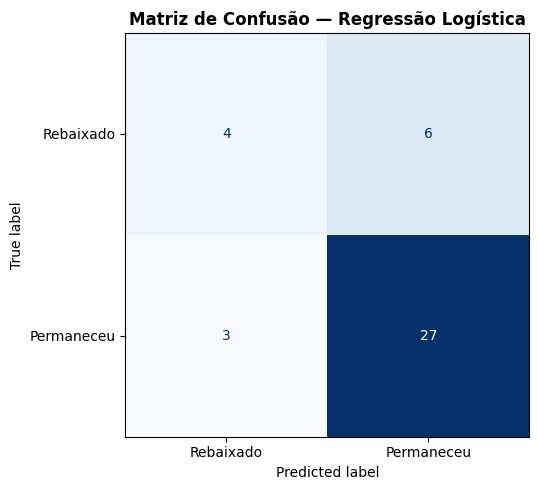

Matriz salva em img/cm_logistica.png


In [3]:
y_pred = lr.predict(X_te)

acc = accuracy_score(y_te, y_pred)
print(f'Acurácia no teste: {acc:.4f} ({acc*100:.2f}%)')
print()
print('Relatório de Classificação:')
print(classification_report(y_te, y_pred, target_names=['Rebaixado', 'Permaneceu']))

# Matriz de Confusão
os.makedirs(os.path.join('..', 'img'), exist_ok=True)
cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rebaixado', 'Permaneceu'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusão — Regressão Logística', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'img', 'cm_logistica.png'), dpi=150)
plt.show()
print('Matriz salva em img/cm_logistica.png')

## Curva ROC e AUC

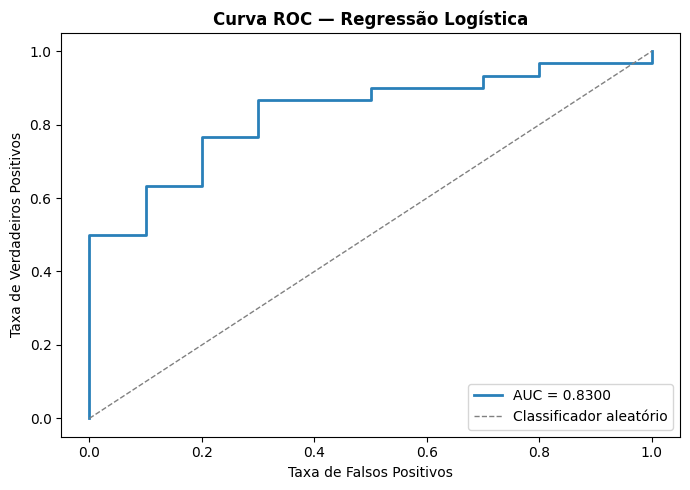

AUC: 0.8300 | Salvo em img/roc_logistica.png


In [4]:
y_prob = lr.predict_proba(X_te)[:, 1]
fpr, tpr, _ = roc_curve(y_te, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#2980b9', lw=2, label=f'AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Classificador aleatório')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC — Regressão Logística', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join('..', 'img', 'roc_logistica.png'), dpi=150)
plt.show()
print(f'AUC: {roc_auc:.4f} | Salvo em img/roc_logistica.png')

## Coeficientes do Modelo

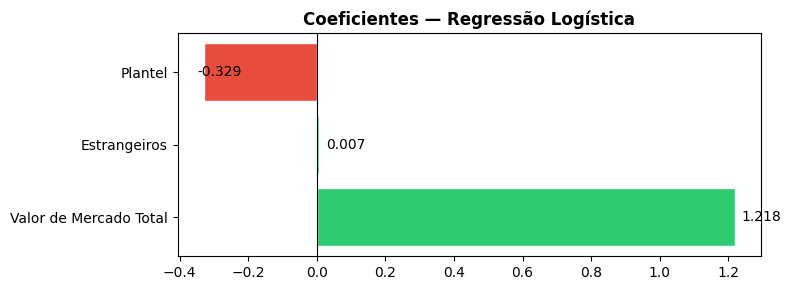

               Feature  Coeficiente
Valor de Mercado Total       1.2183
          Estrangeiros       0.0075
               Plantel      -0.3288
Intercepto: 0.4295


In [5]:
coef = pd.DataFrame({
    'Feature': FEATURES,
    'Coeficiente': lr.coef_[0].round(4)
}).sort_values('Coeficiente', ascending=False)

fig, ax = plt.subplots(figsize=(8, 3))
cores = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef['Coeficiente']]
ax.barh(coef['Feature'], coef['Coeficiente'], color=cores, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Coeficientes — Regressão Logística', fontweight='bold')
for bar, val in zip(ax.patches, coef['Coeficiente']):
    ax.text(val + 0.02 * np.sign(val), bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join('..', 'img', 'coef_logistica.png'), dpi=150)
plt.show()

print(coef.to_string(index=False))
print(f'Intercepto: {lr.intercept_[0]:.4f}')

## Probabilidades por Clube no Conjunto de Teste

In [6]:
probs = lr.predict_proba(X_te)
idx_reb = list(lr.classes_).index(0)

df_res = df_te[['Clube', 'Temporada']].copy()
df_res['Prob_Rebaixamento(%)'] = (probs[:, idx_reb] * 100).round(2)
df_res['Real']    = y_te
df_res['Previsto'] = lr.predict(X_te)
df_res = df_res.sort_values('Prob_Rebaixamento(%)', ascending=False)

print('Probabilidades de rebaixamento (conjunto de teste):')
df_res

Probabilidades de rebaixamento (conjunto de teste):


,Clube,Temporada,Prob_Rebaixamento(%),Real,Previsto
31,Goiás,2023,67.41,1,0
124,Juventude,2024,62.04,0,0
61,Vitória,2024,60.72,0,0
190,Cuiabá,2023,54.96,1,0
96,Atlético Goianiense,2024,53.48,0,0
193,Cuiabá,2024,52.03,1,0
110,América Mineiro,2023,51.17,0,0
166,Criciúma,2024,47.84,0,1
3,Bahia,2023,36.98,1,1
51,Coritiba,2023,36.45,0,1


## Salvando o Modelo e o Scaler

In [7]:
os.makedirs(os.path.join('..', 'modelos'), exist_ok=True)
joblib.dump(lr, os.path.join('..', 'modelos', 'logistica.pkl'))
joblib.dump(scaler, os.path.join('..', 'modelos', 'scaler_logistica.pkl'))
print('Modelo salvo em modelos/logistica.pkl')
print('Scaler salvo em modelos/scaler_logistica.pkl')

Modelo salvo em modelos/logistica.pkl
Scaler salvo em modelos/scaler_logistica.pkl


## Interpretação e Limitações

**Achados principais:**
- Valor de Mercado Total é a feature mais relevante
- `class_weight='balanced'` melhora significativamente o recall para rebaixados

**Limitações:**
- Modelo linear (não captura interações complexas)
- Apenas 3 features utilizadas